In [1]:
!TZ=America/Chicago date

Mon Feb 24 23:16:13 CST 2020


# Introduction

This Jupyter notebook, with code written in Python, contains the calculations of all results presented in Section 3 of our article. First we compare results for correct and incorrect implementations of the finite-population model. Then we turn to the infinite-population model.

In [2]:
%matplotlib notebook
"""
Load the code base.
"""
%run    ./Code/bs.py
%run -i ./Code/rates.py
%run -i ./Code/derivative.py
%run -i ./Code/binned_mixture.py
%run -i ./Code/equilibria.py
%run -i ./Code/bs_plot.py
"""
Suppress automatic display of graphics generated by Matplotlib. All
graphics are saved to disk, and are displayed by explicit commands.
"""
plt.interactive(False)
"""
Define the name of the subdirectory that holds various files associated
with this notebook, and create the directory if it does not exist already.
"""
DIR = './SM1data/'
!if [ ! -d {DIR} ]; then mkdir {DIR}; fi

# The finite-population model

In the opening of Section 5, "Numerical Simulations," Basener and Sanford stipulate that their master equation is modified so that the derivative $\text{d}P_i(t)/\text{d}t$ is defined only when the relative frequency of class $i$ is at least $10^{-9}.$ Furthermore, any frequency $P_i(t)$ with an undefined derivative is defined to be equal to zero. It follows that class frequencies of zero must remain zero forever, inasmuch as their derivatives are undefined. In other words, extinction of a class of organism is permanent.

The software used by Basener and Sanford erroneously calculates derivatives for frequencies of zero, and sometimes permits the frequency of a class to rise from zero at time $t$ to a positive quantity at time $t+1.$

**SAY MORE**

In [3]:
# %load './Code/modified_euler.py'
class ModifiedEuler(object):
    """
    Modification of Euler forward method for numerical integration.
    
    EXPAND:
    1. Euler forward method is applied when `threshold` is zero.
    2. Callable and indexable.
    3. Customized to application. It is assumed that subthreshold
    frequencies are at the tails of the frequency distribution.
    """
    def __init__(self, derivative, initial_freqs, threshold=0):
        """
        NEED
        """
        self.derivative = derivative
        self.threshold = threshold
        #
        # Array `s` always contains the current solution. The base type
        # of `s` is the base type of `initial_value`. Subthreshold
        # frequencies are zeroed.
        self.s = initial_freqs + 0
        self.s[self.s < threshold * np.sum(self.s)] = 0
        #
        # Slice `support` indicates which classes have positive
        # frequencies, i.e., which classes to include in the calculation
        # of derivatives.
        self.support = slice_to_support(self.s)
        #
        # Array `solutions` contains the end-of-year solutions. The base
        # type is float.
        self.solutions = np.empty((1, len(self.s)), dtype=float)
        self.solutions[0] = self.s
        self.n_solutions = 1
        
    def __call__(self, n_years=1000, steps_per_year=2**7):
        """
        NEED
        
        There are `steps_per_year` numerical integration steps per year.
        At the end of each year, the current solution is stored.
        """
        self._extend_storage(n_years)
        step_size = 1 / steps_per_year
        for _ in range(n_years):
            for _ in range(steps_per_year):
                self.integration_step(step_size)
            self.scale_current_solution()
            self.solutions[self.n_solutions] = self.s
            self.n_solutions += 1

    def integration_step(self, step_size):
        """
        Performs an integration step; zeroes subthreshold frequencies.
        """
        # The derivative calculation is restricted to classes in the
        # support of the frequency distribution. 
        self.s += step_size * self.derivative(0, self.s, self.support)
        #
        # Zero frequencies that have fallen below threshold.
        included = self.s[self.support]
        included[included < self.threshold * fsum(included)] = 0
        #
        # Update the support if any frequencies of classes in the
        # support have been zeroed.
        if included[-1] == 0 or included[0] == 0:
            self.support = slice_to_support(self.s)
    
    def scale_current_solution(self):
        """
        Scales the current solution to avoid overflow and underflow.
        """
        # Make the maximum frequency of the solution have an exponent
        # of 768. Scaling a floating point number by an integer power
        # of 2 does not change its mantissa. Thus there is no loss in
        # precision.
        _, max_exponent = frexp(self.s.max())
        self.s *= 2.0 ** (768 - max_exponent)
        
    def __getitem__(self, which):
        """
        Returns the result of indexing solutions by `which`.
        
        The frequency vector for each year is normalized.
        """
        s = self.solutions[which]
        if s.ndim == 1:
            return s / fsum(s)
        return s / s.sum(axis=1)[:,None]

    def __len__(self):
        """
        Returns the number of stored solutions (one per year).
        """
        return len(self.solutions)

    def _extend_storage(self, n):
        """
        Allocate storage for solutions for an additional `n` years.
        """
        rows, cols = self.solutions.shape
        new = np.zeros((rows+n, cols), dtype=float)
        new[:rows] = self.solutions
        self.solutions = new


class PoorlyModifiedEuler(ModifiedEuler):
    def integration_step(self, step_size):
        """
        Incorrectly performs an integration step.
        
        Derivatives should not be calculated for frequencies that are
        below threshold, but they are. All frequencies are updated, and
        only those that are below threshold after the update are zeroed.
        That is, previously zeroed frequencies are not held at zero.
        """
        self.s += step_size * self.derivative(0, self.s)
        self.s[self.s < self.threshold * fsum(self.s)] = 0

Note that if the size of the time step is less than the size of the threshold relative frequency, then (for the range of birth rates under consideration) the solutions are identical for the two methods for numerical integration over time. That is, a frequency of zero cannot rise to threshold in a single time step if the size of the step is set sufficiently small. 

## Run the good and poor solvers

In [4]:
def finite_setup(rates, threshold=1e-9):
    """
    Returns solvers in classes ModifiedEuler and PoorlyModifedEuler.
    """    
    # Bin the distribution of probability over mutational effects.
    beneficial_weight = '1e-3'
    p = binned_mixture(gamma_ccdf, len(rates.effects), beneficial_weight)
    #
    # Define the derivative operator in terms of the distribution of
    # probability over mutational effects.
    derivative = Derivative(p, rates)
    #
    # Obtain the frequency distribution of the initial population by
    # binning a normal probability distribution. The parameters of the
    # distribution come from Section 5 of Basener and Sanford.
    bin_walls = rates.fitness_walls
    init_freqs = binned_normal(bin_walls, mean='0.044', std='0.005')
    init_freqs = convert(init_freqs, float)
    #
    # Return solver objects in the two classes.
    good_solver = ModifiedEuler(derivative, init_freqs, threshold)
    poor_solver = PoorlyModifiedEuler(derivative, init_freqs, threshold)
    return good_solver, poor_solver


max_birth_rate = mp_float('0.2')
rates = Rates(max_birth_rate, death='0.1')
good_solver, poor_solver = finite_setup(rates)

In [5]:
%%time
"""
Run the good solver with a large number of integration steps per year.
""" 
good_solver(n_years=12000, steps_per_year=2**5) #### INCREASE TO 2**10

CPU times: user 33.2 s, sys: 1.36 s, total: 34.6 s
Wall time: 24.1 s


In [6]:
%%time
"""
Run the poor solver with one integration step per year, as do Basener
and Sanford.
""" 
poor_solver(n_years=25000, steps_per_year=1)

CPU times: user 16.4 s, sys: 704 ms, total: 17.1 s
Wall time: 4.52 s


### Check for convergence

In [7]:
"""
Output the maximum absolute error of the solution for an earlier year
relative to the solution for the last year. The earlier year is 1000
years prior to the last year of the run.
"""
print('Convergence checks')
print('\tGood solver:', 
      maximum_absolute_relative_error(good_solver[-1001], good_solver[-1]))
print('\tPoor solver:', 
      maximum_absolute_relative_error(poor_solver[-1001], poor_solver[-1]))

Convergence checks
	Good solver: 4.94097307135815e-15
	Poor solver: 8.232174350311954e-14


### Plot solutions in selected years

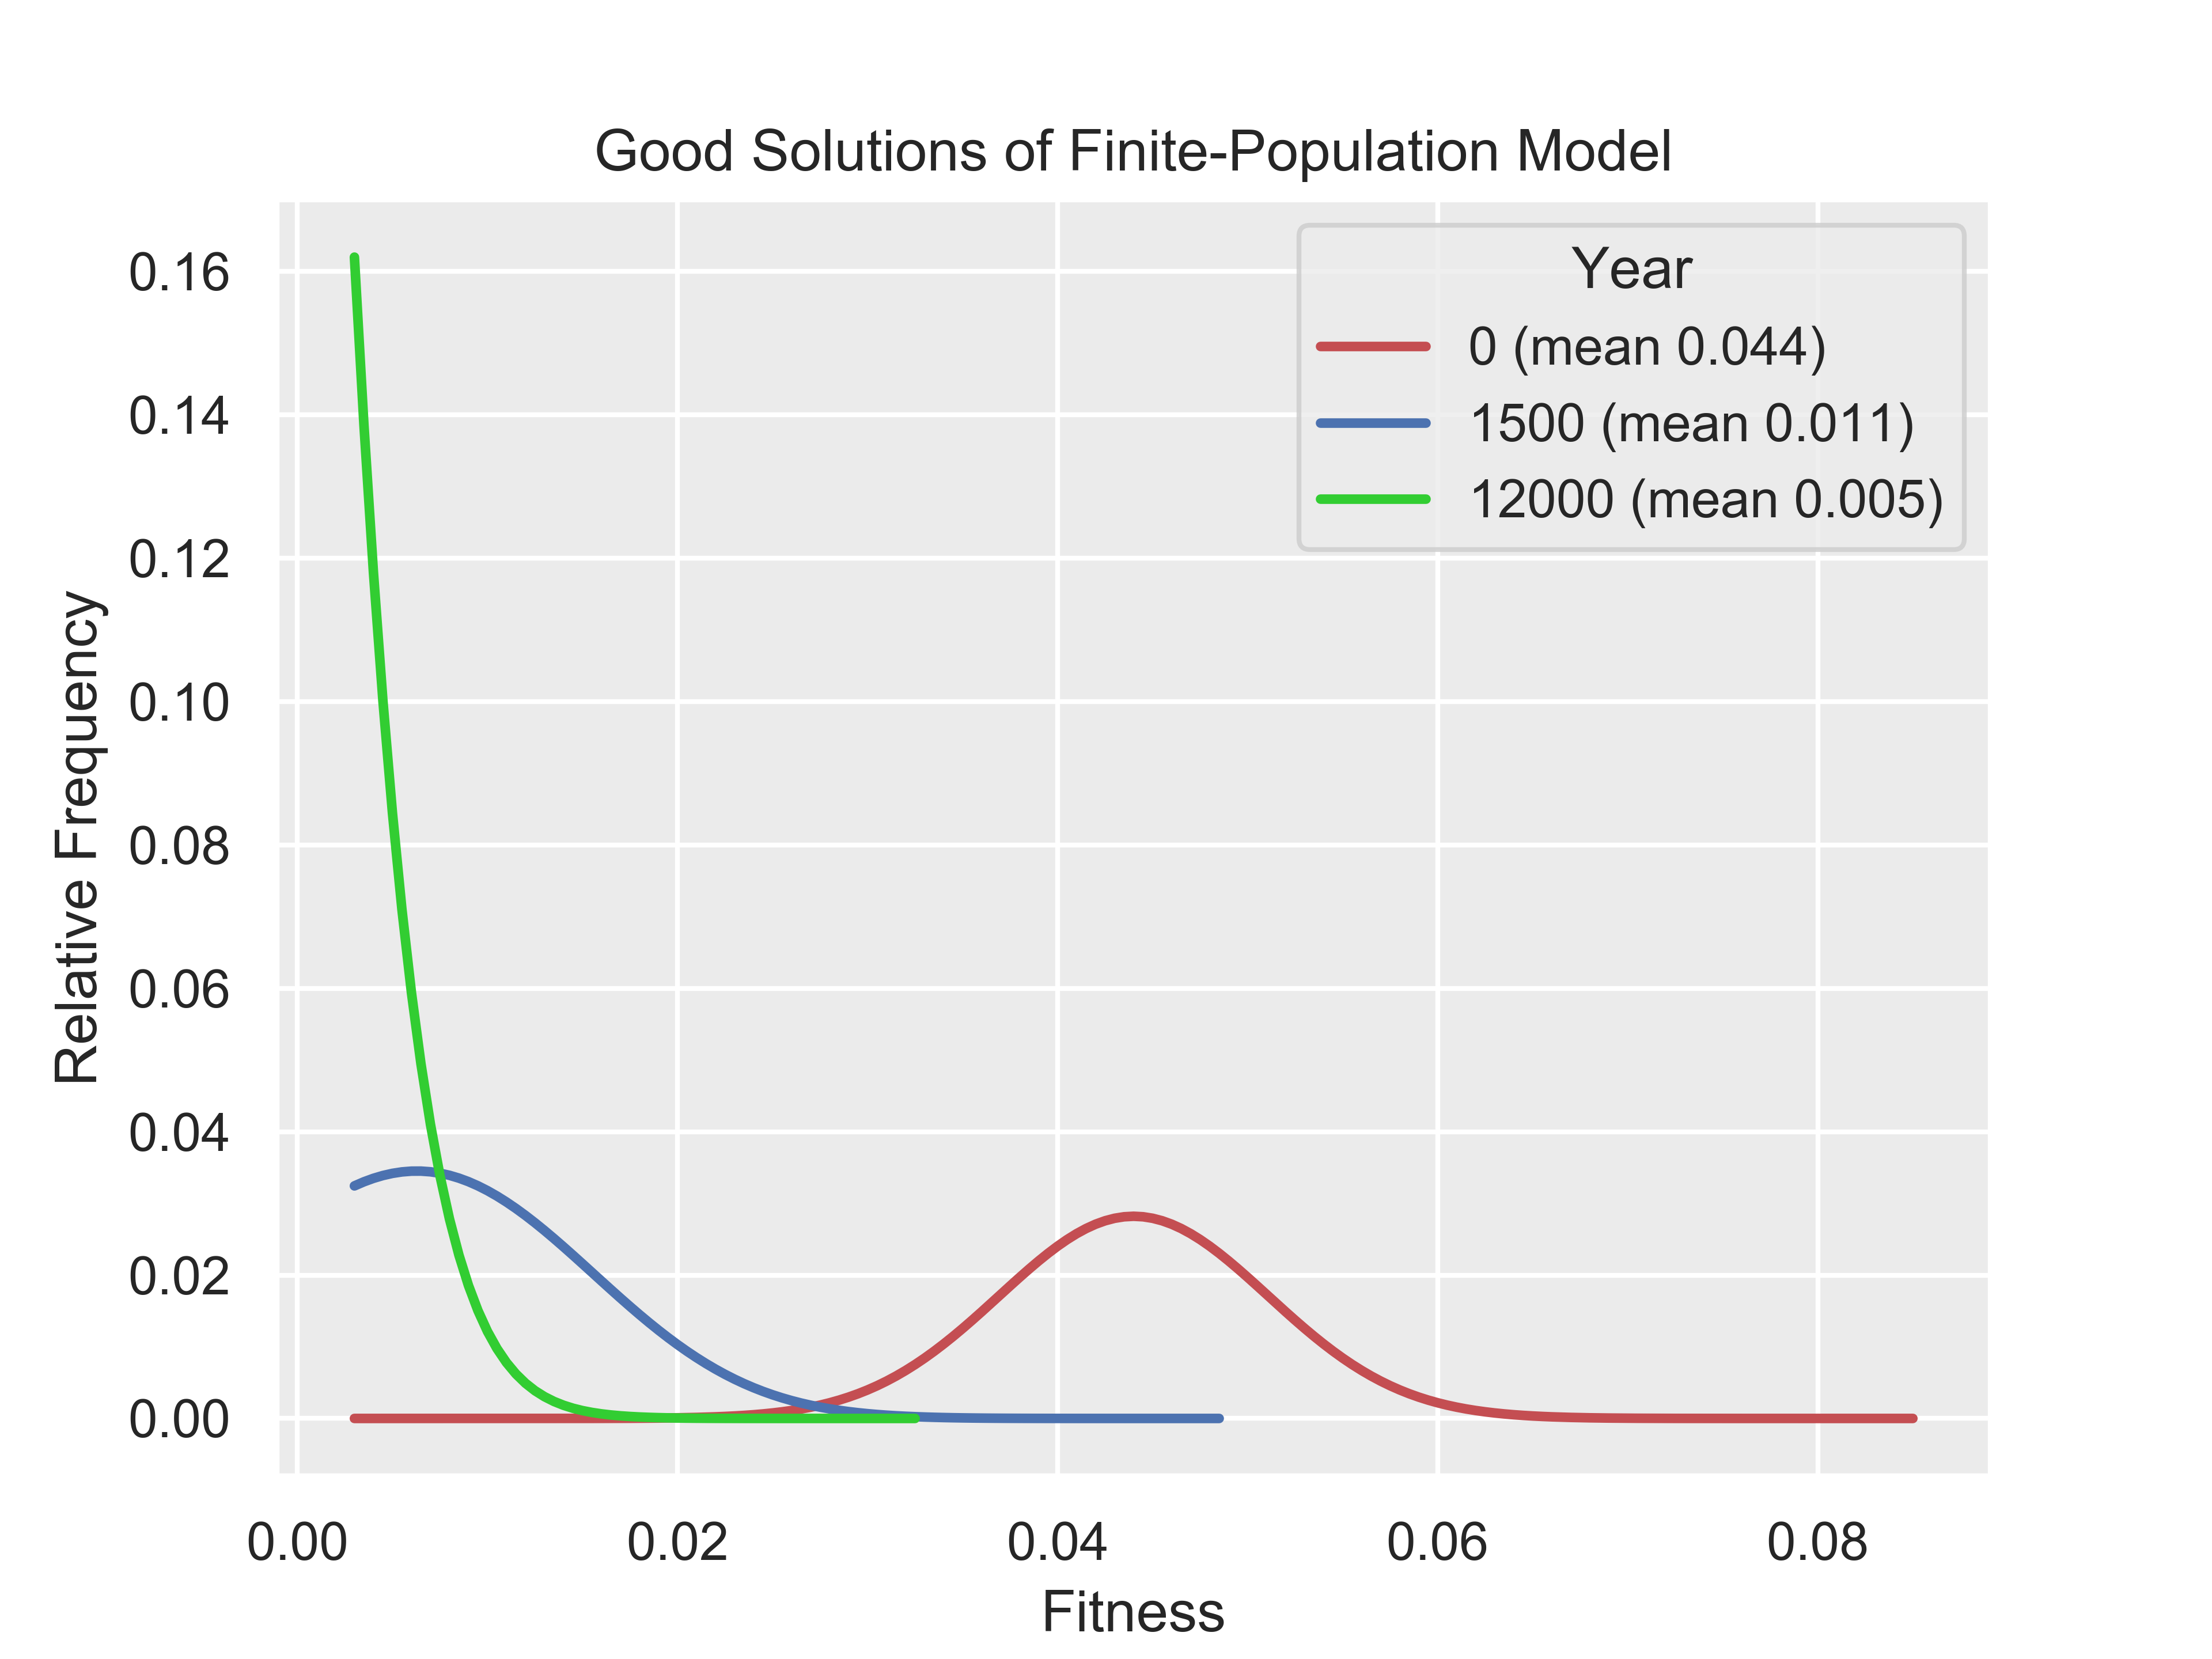

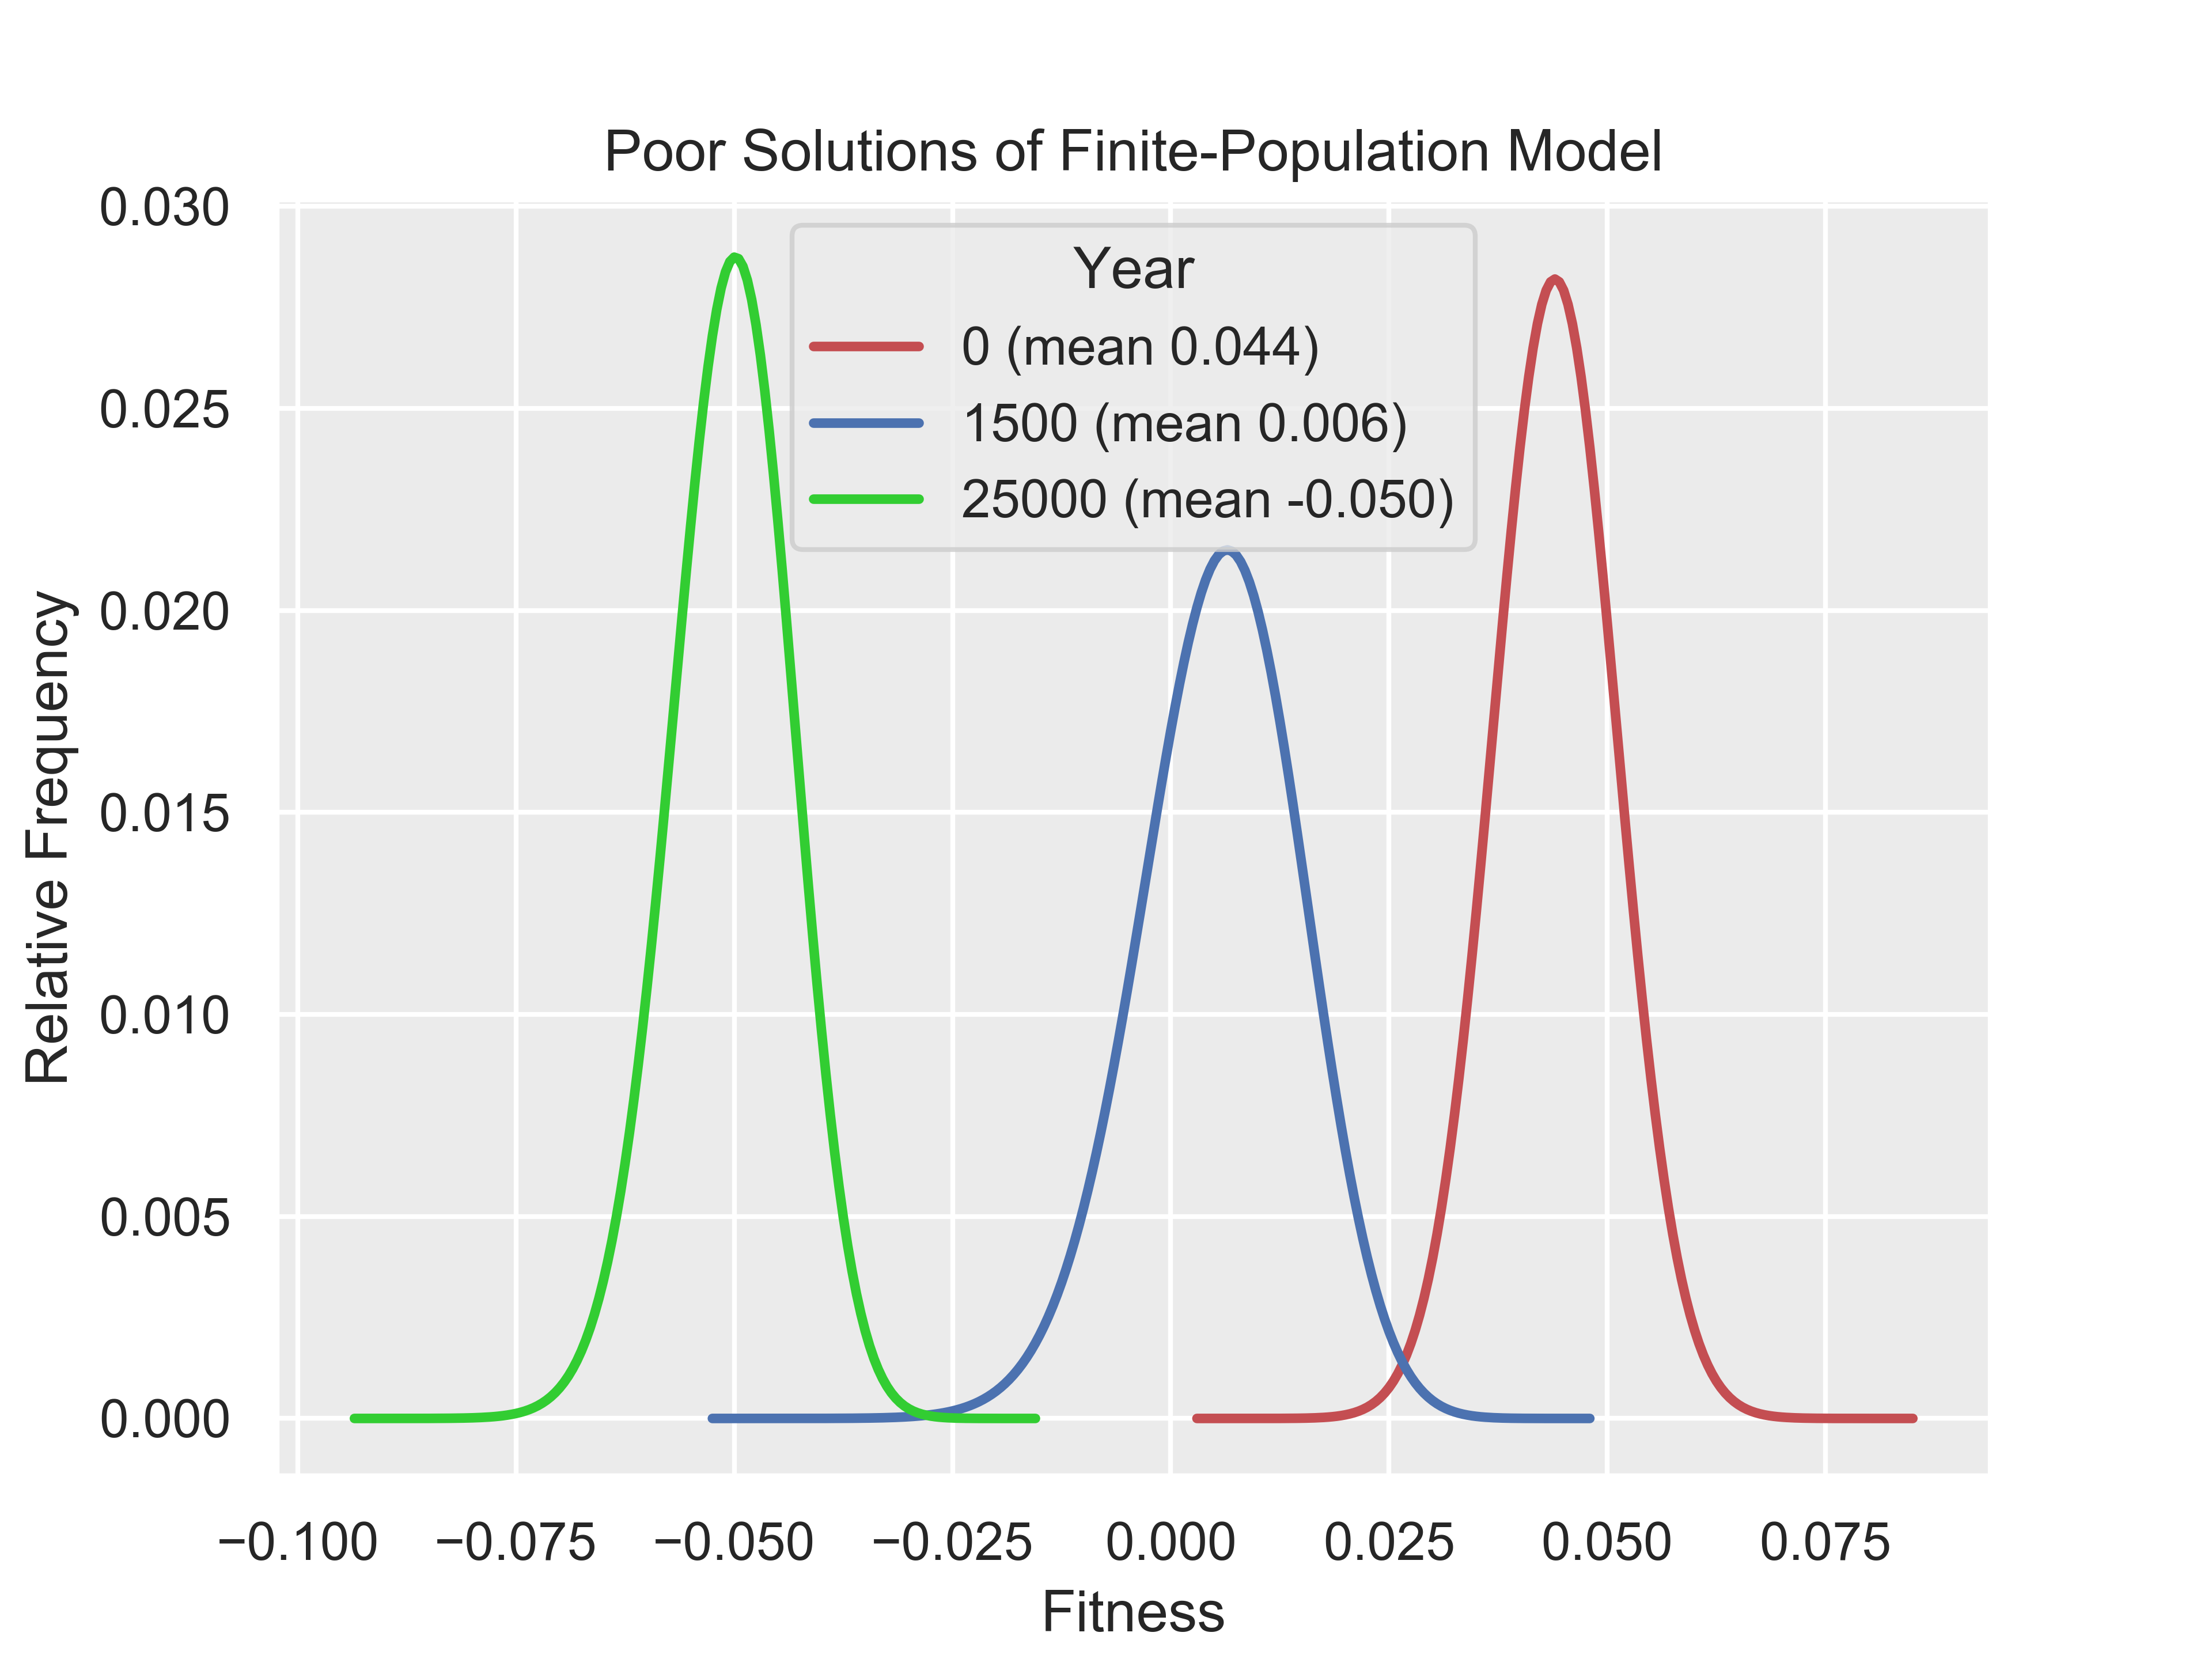

In [8]:
fig, ax = bs_plot(good_solver, rates.fitness, 1500)
ax.set_title('Good Solutions of Finite-Population Model')
save_and_display(fig, DIR + 'Fig1.png')

fig, ax = bs_plot(poor_solver, rates.fitness, 1500)
ax.set_title('Poor Solutions of Finite-Population Model')
save_and_display(fig, DIR + 'Fig2.png')

## FTNSwM does not hold for finite-pop model

**Ignore this for now**

\begin{align}
    \frac{\text{d}\bar{m}}{\text{d}t}
       &= \text{Var}(m) + \frac{1}{\sum_i P_i} \sum_i
             \left(\left(\sum_j b_j f_{ij} P_j\right) - b_i P_i\right) (m_i - \bar{m}) \nonumber \\
       &= \text{Var}(m) + \frac{1}{\sum_i P_i} \sum_i
             \left(\frac{\text{d}P_i}{\text{d}t} - m_i P_i\right) (m_i - \bar{m}) 
    \label{eq:FTNSwM}
\end{align}

In [9]:
def theorem_value(frequencies, derivatives, fitnesses):
    norm = fsum(frequencies)
    mean, var = mean_var(frequencies, fitnesses)
    rate_differences = derivatives - fitnesses * frequencies
    fitness_deviates = fitnesses - mean
    return var + fsum(rate_differences * fitness_deviates) / norm

def check_theorem(frequencies, derivative, fitnesses, delta_t=2**-20,
                  threshold=2**-20):
    derivatives = derivative(None, frequencies)
    theorem = theorem_value(frequencies, derivatives, fitnesses)
    mean = mp_mean(frequencies, fitnesses)
    new_freqs = frequencies + time_step * derivatives
    new_freqs[new_freqs < threshold * fsum(new_freqs)] = 0
    new_mean = mp_mean(new_freqs, fitnesses)
    return {'theorem' : thm, 'actual' : (new_mean - mean) / delta_t}    

In [10]:
def SAVE():
    with mp.workdps(600):
        max_birth_rate = mp.mpf('0.2')
        rates = Rates(max_birth_rate)
        fitnesses = rates.fitness
        mutation_probs = np.empty_like(rates.effects, dtype=mp.mpf)
        mutation_probs[:] = mp.mpf(0)
        mutation_probs[len(mutation_probs) // 2 - 1] = mp.mpf(1)
        freqs = np.empty_like(fitnesses)
        freqs[:] = mp.mpf(0)
        freqs[-1] = mp.mpf(1)
        mean = mp_mean(freqs, fitnesses)
        derivative = Derivative(mutation_probs, rates)
        dt = mp.mpf('2') ** -500
        threshold = 0
        new_freqs = freqs + dt * derivative(None, freqs)
        new_freqs[new_freqs < threshold * mp.fsum(new_freqs)] = 0
        new_mean = mp_mean(new_freqs, fitnesses)
        print((new_mean - mean) / dt)
        print(theorem_value(freqs, derivative(None, freqs), fitnesses))

# The infinite-population model

In [11]:
%%time
fitness_limits = ['0.025', '0.050', '0.075', '0.100',
                  '0.125', '0.150', '0.175', '0.200']
log_weights = ['-3', '-6', '-9', '-12']
weights = ['1e{}'.format(w) for w in log_weights]
labels = ['$\gamma = 10^{' + '{}'.format(w) + '}$' for w in log_weights]

eq = Equilibria(gamma_ccdf, weights, labels, fitness_limits, '0.1')

./Code/bs_plot.py:122: UserWarning: equilibrium relative error 1.0588012949705316e-15
./Code/bs_plot.py:122: UserWarning: equilibrium relative error 1.4535882824639324e-15
./Code/bs_plot.py:122: UserWarning: equilibrium relative error 8.142736290237168e-16
./Code/bs_plot.py:122: UserWarning: equilibrium relative error 9.170261018483468e-16
./Code/bs_plot.py:122: UserWarning: equilibrium relative error 8.842276087326369e-16
./Code/bs_plot.py:122: UserWarning: equilibrium relative error 1.5341302265090332e-15
./Code/bs_plot.py:122: UserWarning: equilibrium relative error 9.47316112889744e-16
./Code/bs_plot.py:122: UserWarning: equilibrium relative error 9.095048828124903e-16
./Code/bs_plot.py:122: UserWarning: equilibrium relative error 1.4681958489170332e-15
./Code/bs_plot.py:122: UserWarning: equilibrium relative error 1.9572469729797092e-15
./Code/bs_plot.py:122: UserWarning: equilibrium relative error 1.1525444131555095e-15
./Code/bs_plot.py:122: UserWarning: equilibrium relative err

CPU times: user 25min 1s, sys: 45.8 s, total: 25min 46s
Wall time: 7min 35s


./Code/bs_plot.py:122: UserWarning: equilibrium relative error 1.4798496151064683e-15


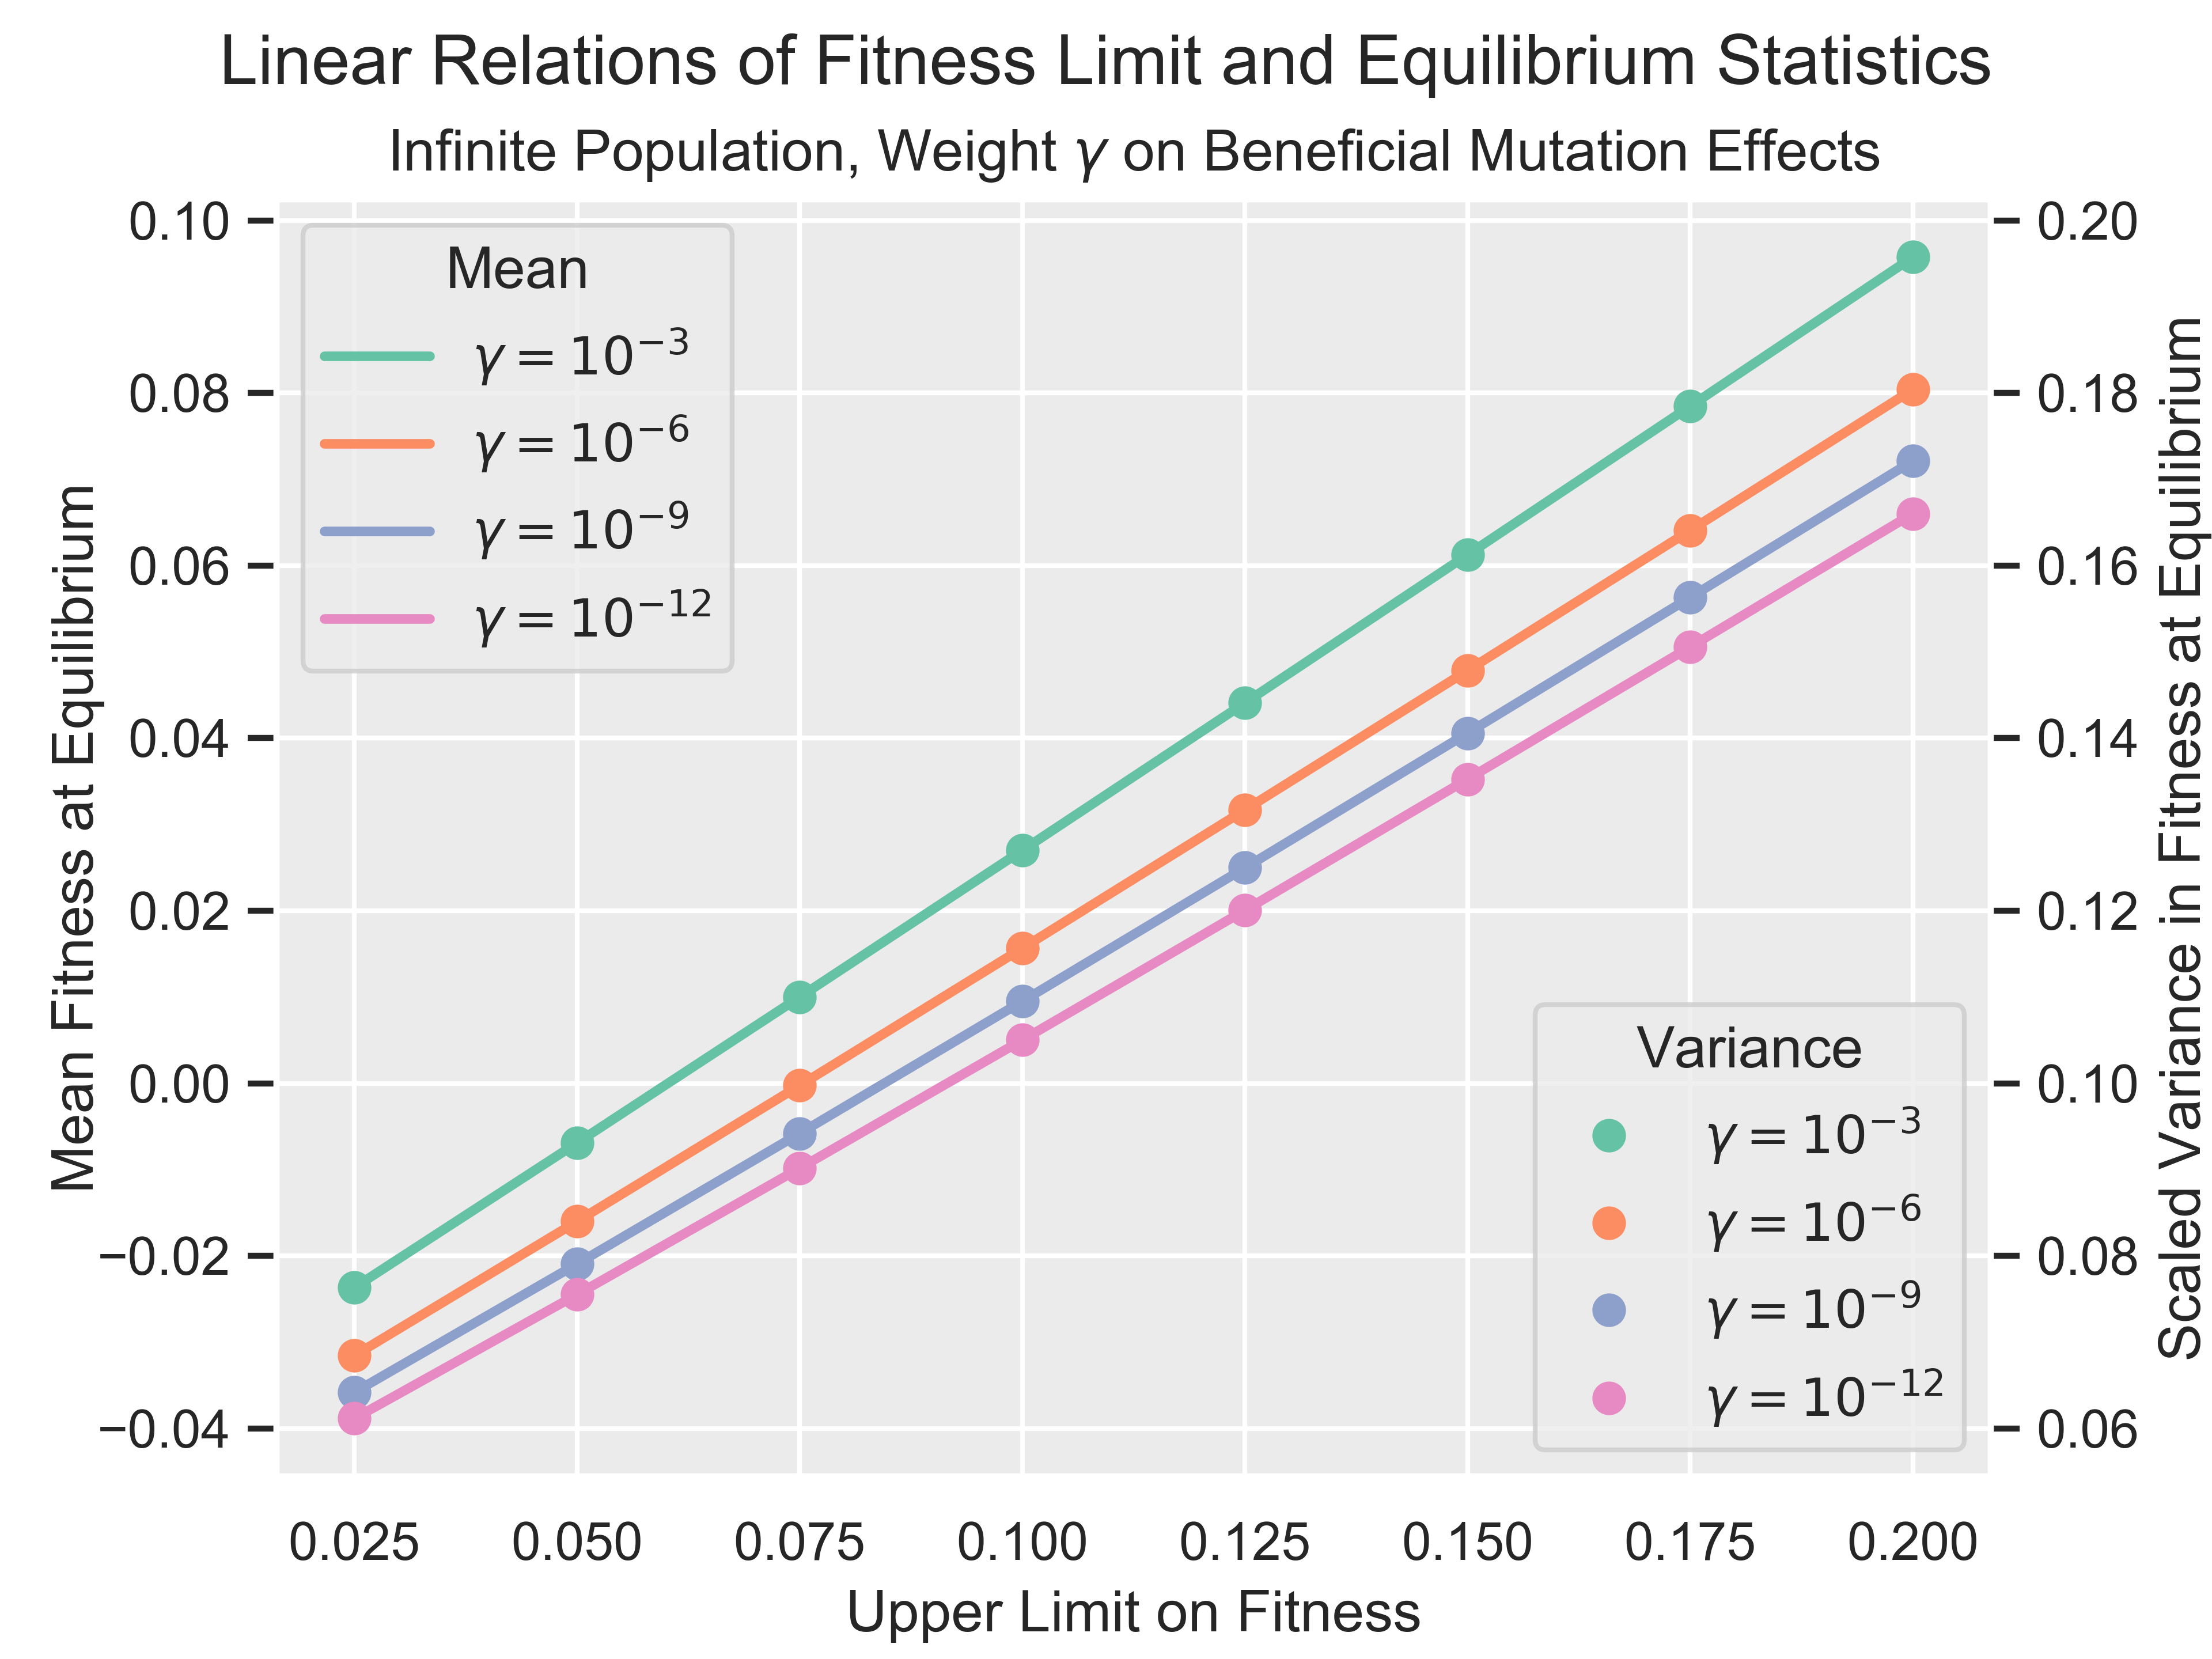

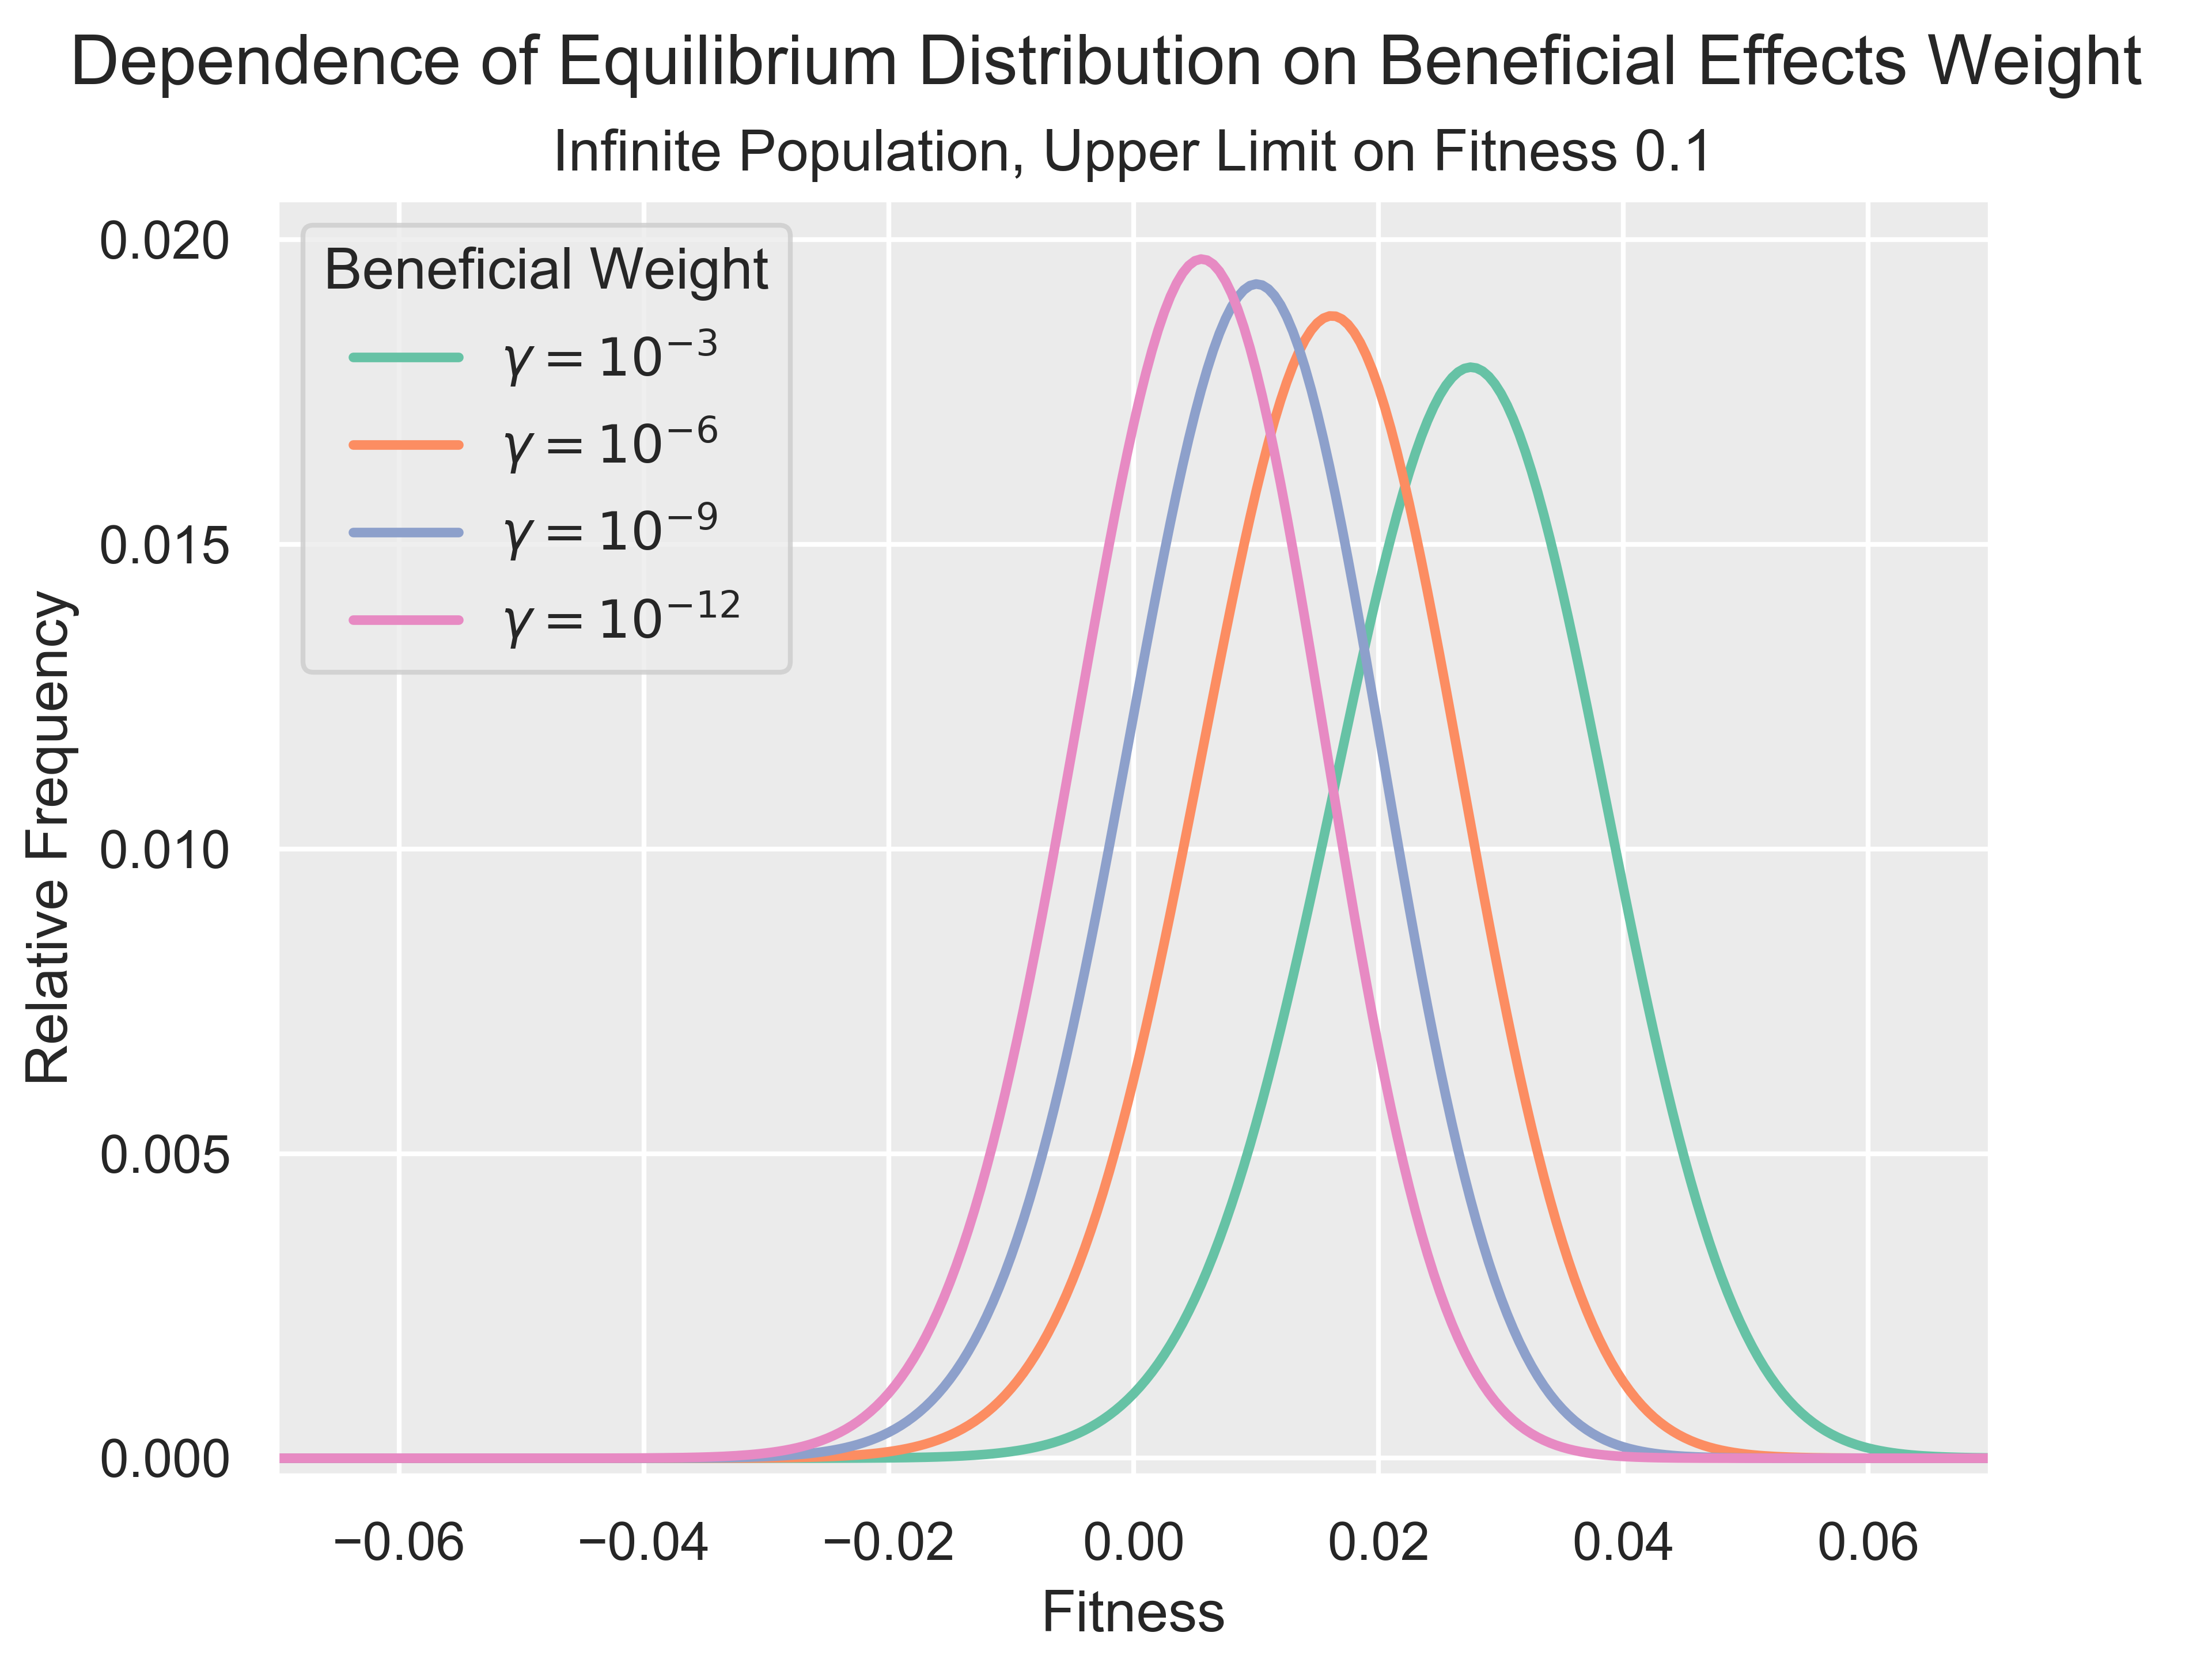

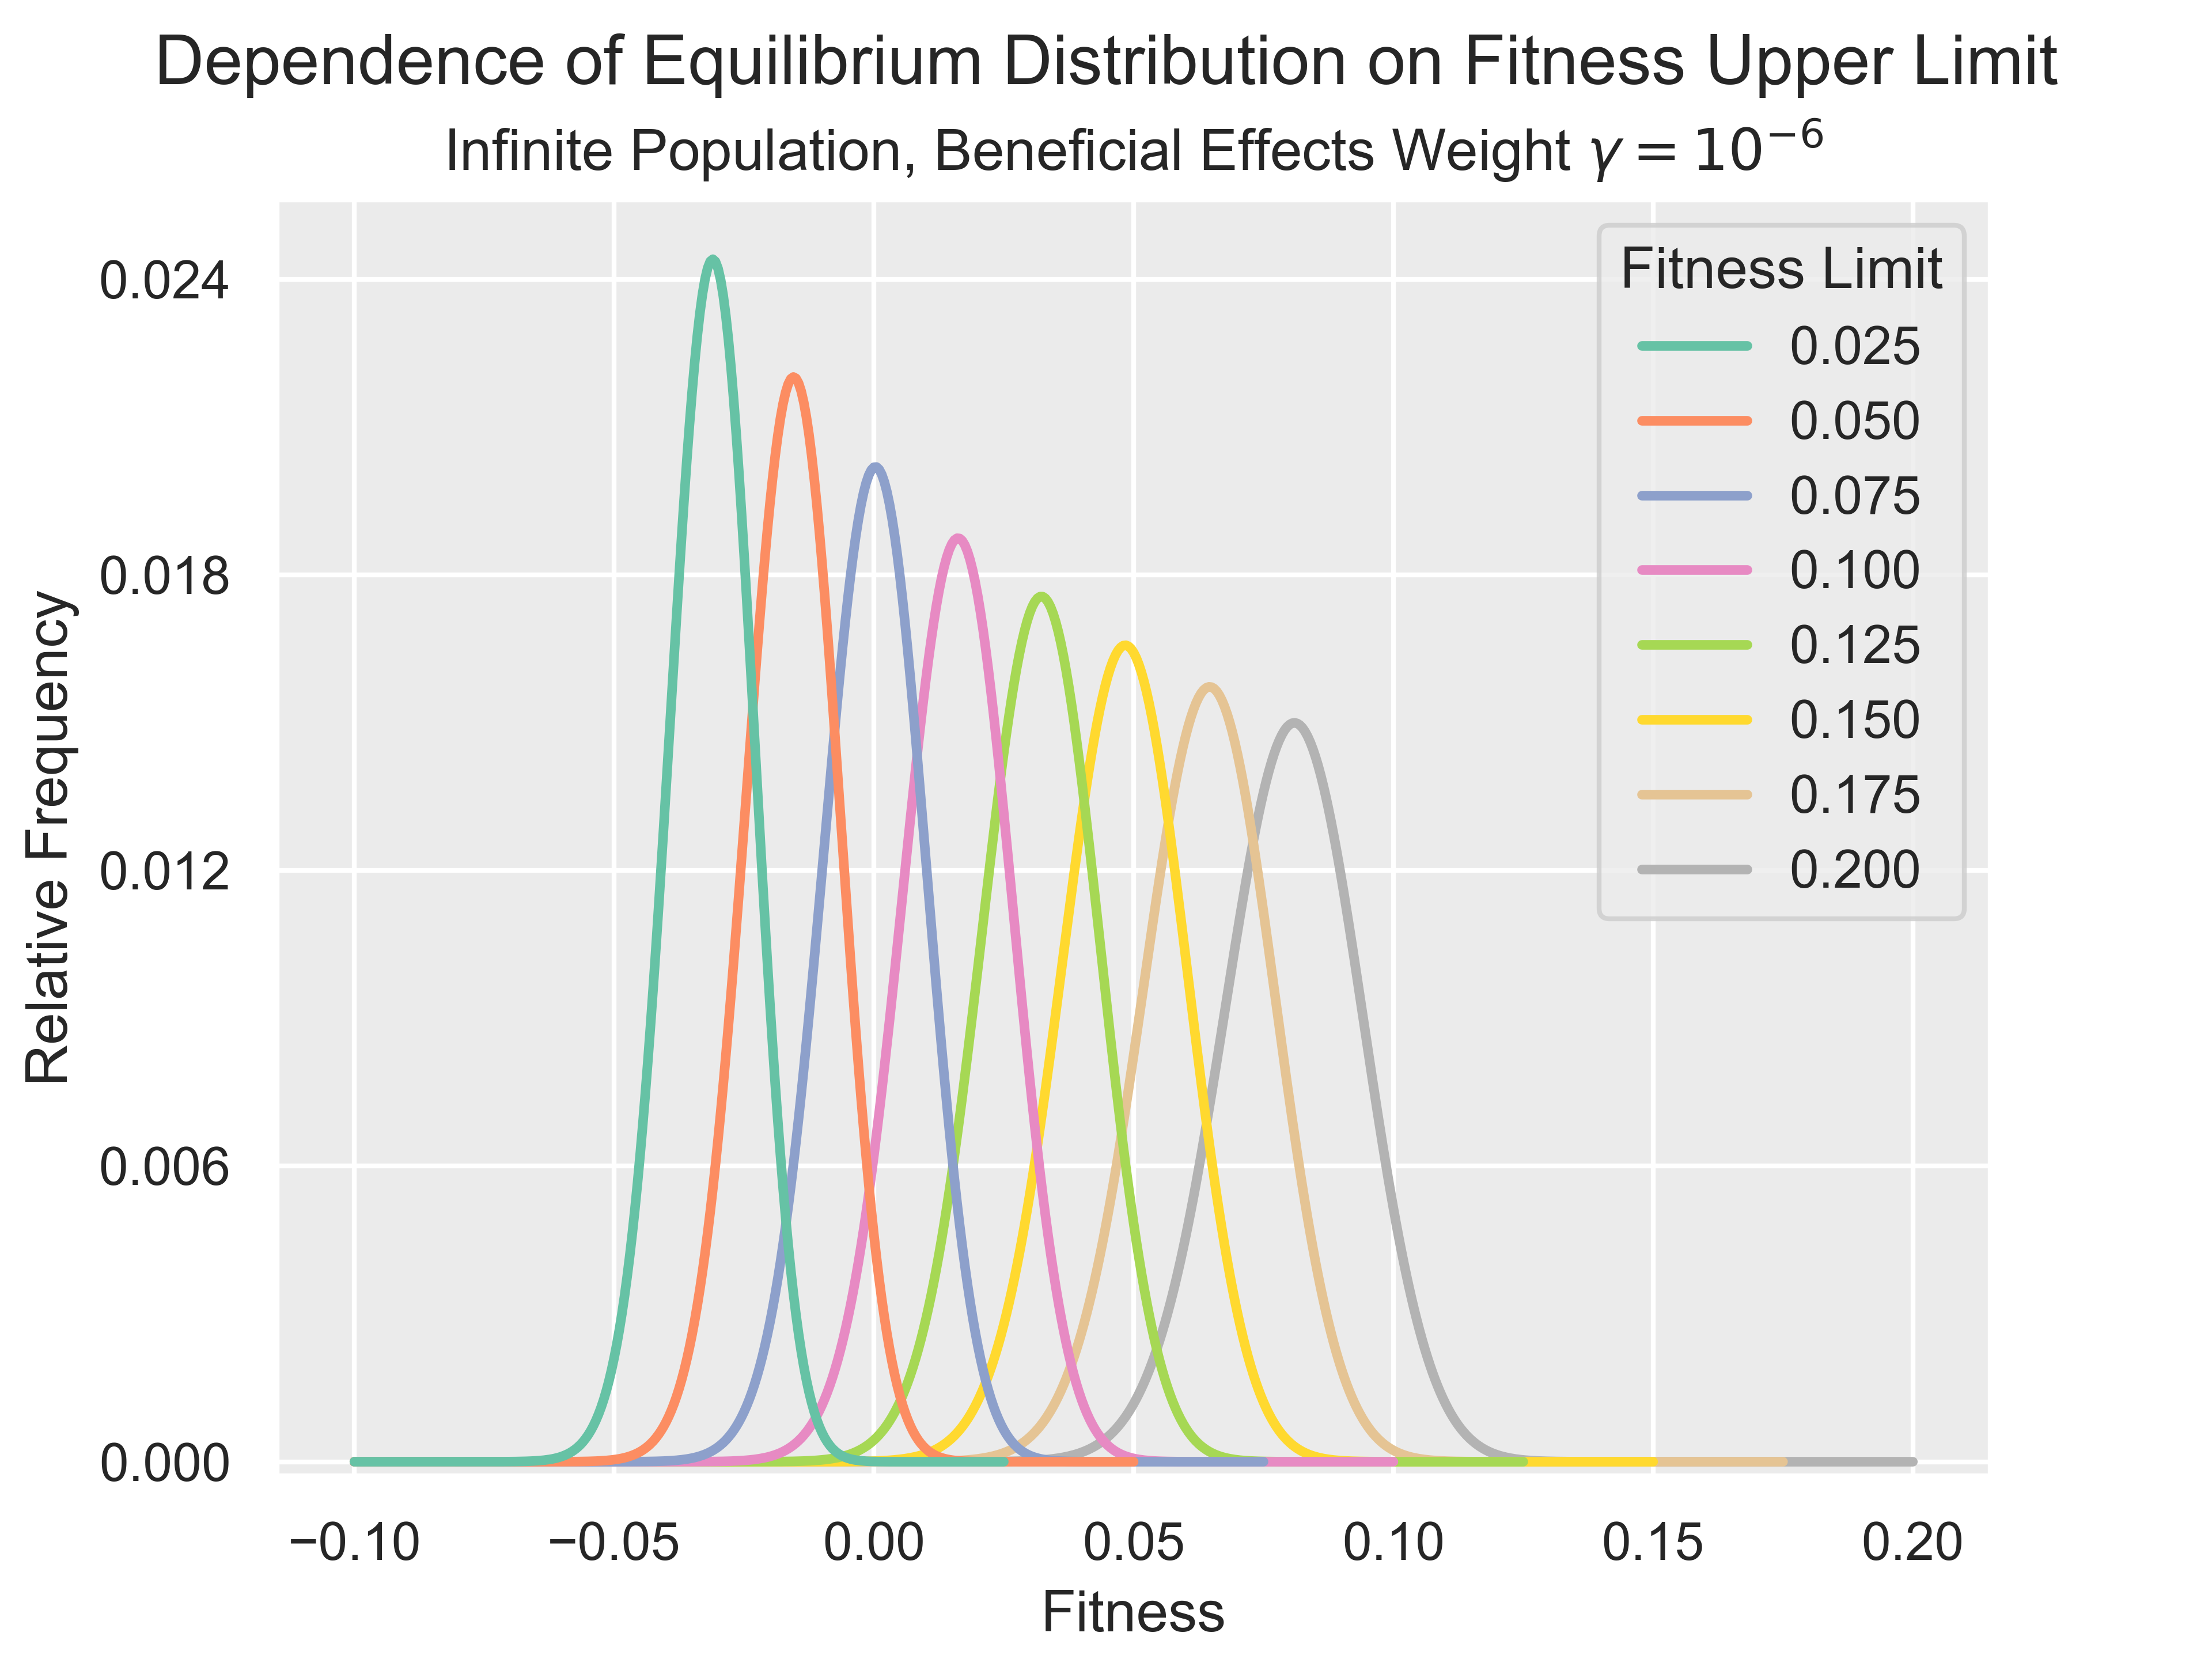

In [12]:
"""
Generate Figure 3 of the article.
"""
eq.plot_stats(
    'Linear Relations of Fitness Limit and Equilibrium Statistics',
    'Infinite Population, Weight $\gamma$ on Beneficial Mutation Effects')
eq.ax_mean.yaxis.set_label_coords(-0.1, 0.5)
eq.save_and_display(DIR + 'Fig3.png')

"""
Generate Figure 4 of the article.
"""
eq.plot_column(3)
eq.ax.set_xlim([-0.07, 0.07])
t = 'Dependence of Equilibrium Distribution on Beneficial Effects Weight'
eq.fig.suptitle(t)
eq.save_and_display(DIR + 'Fig4.png')

"""
Generate Figure 5 of the article.
"""
eq.plot_row(1)
t = 'Dependence of Equilibrium Distribution on Fitness Upper Limit'
eq.fig.suptitle(t)
eq.save_and_display(DIR + 'Fig5.png')

In [13]:
def regression_report(log_weights, fitness_limits):
    def print_results(regression, log_weight):
        print('Beneficial weight 10^{}'.format(log_weight))
        print('\tslope       :', regress.slope)
        print('\tintercept   :', regress.intercept)
        print('\tcorrelation :', regress.rvalue)

    print('Linear regression of mean on variance')
    for i, log_weight in enumerate(log_weights):
        regress = stats.linregress(eq.var[i], eq.mean[i])
        print_results(regress, log_weight)

    print('\nLinear regression of variance on max fitness')
    for i, log_weight in enumerate(log_weights):
        regress = stats.linregress(fitness_limits, eq.var[i])
        print_results(regress, log_weight)

regression_report(log_weights, eq.limits.astype(float))

Linear regression of mean on variance
Beneficial weight 10^-3
	slope       : 1019.1015858424515
	intercept   : -0.10000000002365514
	correlation : 1.0
Beneficial weight 10^-6
	slope       : 1017.0654166266036
	intercept   : -0.09999999999606757
	correlation : 1.0
Beneficial weight 10^-9
	slope       : 1017.0633844482369
	intercept   : -0.09999999998492959
	correlation : 0.9999999999999998
Beneficial weight 10^-12
	slope       : 1017.063382231312
	intercept   : -0.09999999996080838
	correlation : 1.0

Linear regression of variance on max fitness
Beneficial weight 10^-3
	slope       : 0.0006698581425665232
	intercept   : 5.7844500573204493e-05
	correlation : 0.9999883243233325
Beneficial weight 10^-6
	slope       : 0.0006294379976519807
	intercept   : 5.1089104397580965e-05
	correlation : 0.9999691024049321
Beneficial weight 10^-9
	slope       : 0.0006069860811202147
	intercept   : 4.736126631334164e-05
	correlation : 0.9999497252879908
Beneficial weight 10^-12
	slope       : 0.000589741